In [1]:
# Core
import json
import numpy as np
import pandas as pd
import joblib

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import optuna

/e/conda/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scaler = joblib.load("../data/processed/X_scaler.pkl")
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")
X_trainVal = np.load("../data/processed/X_trainVal.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")
y_trainVal = np.load("../data/processed/y_trainVal.npy")
y_scaler = joblib.load("../data/processed/y_scaler.pkl")

with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)


In [3]:
with open("../models/best_rf1_params.json", "r") as f:
    rf_params = json.load(f)

rf_params["criterion"] = "squared_error"
rf_params["n_jobs"] = -1
rf_params["random_state"] = 42

final_rf1 = RandomForestRegressor(**rf_params)
final_rf1.fit(X_trainVal, y_trainVal)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [5]:
rf_preds_raw = final_rf1.predict(X_test)
rf_preds = y_scaler.inverse_transform(rf_preds_raw)
mse = mean_squared_error(y_test, rf_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_preds)
mae = mean_absolute_error(y_test, rf_preds)

print("RF Test Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

joblib.dump(final_rf1, "../models/rf_expert.pkl")

RF Test Metrics
MSE : 6.999929759845803
RMSE: 2.6457380368898584
MAE : 1.9089036188297885
R2  : 0.9184093042398911


['../models/rf_expert.pkl']

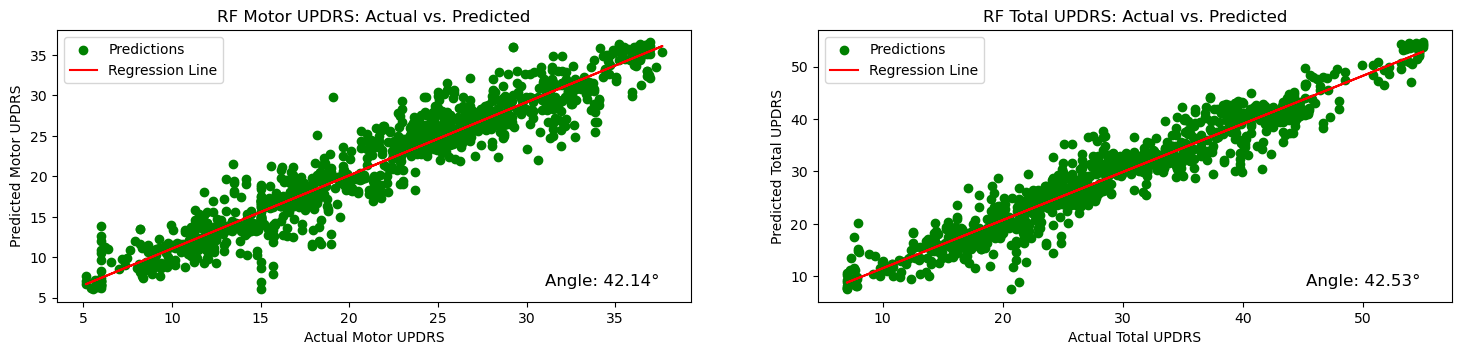

In [ ]:
plt.figure(figsize=(18, 12))

def plot_with_angle(ax, actual, predicted, label, color, model_name):
    ax.scatter(actual, predicted, label='Predictions', color=color)

    slope, intercept = np.polyfit(actual, predicted, 1)
    regression_line = slope * actual + intercept
    ax.plot(actual, regression_line, color='red', label='Regression Line')

    angle = np.degrees(np.arctan(slope))
    ax.text(0.95, 0.05, f'Angle: {angle:.2f}°', transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{model_name} {label}: Actual vs. Predicted')
    ax.legend()

# NN plots
plt.subplot(3, 2, 1)
plot_with_angle(plt.gca(), y_test[:, 0], rf_preds[:, 0], 'Motor UPDRS', 'green', 'RF')

plt.subplot(3, 2, 2)
plot_with_angle(plt.gca(), y_test[:, 1], rf_preds[:, 1], 'Total UPDRS', 'green', 'RF')